In [636]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures

%matplotlib inline

In [637]:
# read in all the words
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [638]:
len(words)

32033

In [639]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [640]:
# build the dataset
BLOCK_SIZE_LOCAL = (
    3  # context length: how many characters do we take to predict the next one?
)

X, Y = [], []
for w in words:
    # print(w)
    context = [0] * BLOCK_SIZE_LOCAL
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [641]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# build the dataset
BLOCK_SIZE = (
    3  # context length: how many characters do we take to predict the next one?
)


def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * BLOCK_SIZE
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [643]:
C = torch.randn((27, 2))

In [644]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [645]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [646]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [647]:
h

tensor([[ 0.0448,  0.9420, -0.9989,  ..., -0.8718, -0.2431, -0.9938],
        [-0.6003, -0.9293,  0.7824,  ..., -0.9922, -0.9987, -0.9662],
        [ 0.9619, -0.9981,  0.9610,  ..., -0.5043, -0.6269,  0.9713],
        ...,
        [-0.2245,  0.7202, -0.9936,  ..., -0.9323, -0.5513, -0.9979],
        [ 0.2859,  0.8192, -0.9995,  ..., -0.5355,  0.3597, -0.9937],
        [-0.5128,  0.2780, -0.4800,  ..., -0.9736, -0.9763, -0.9814]])

In [648]:
h.shape

torch.Size([228146, 100])

In [649]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [650]:
logits = h @ W2 + b2

In [651]:
logits.shape

torch.Size([228146, 27])

In [652]:
counts = logits.exp()

In [653]:
prob = counts / counts.sum(1, keepdims=True)

In [654]:
prob.shape

torch.Size([228146, 27])

In [655]:
# loss = -prob[torch.arange(32), Y].log().mean()
# loss

In [656]:
# ------------ now made respectable :) ---------------

In [657]:
Xtr.shape, Ytr.shape  # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [658]:
EMB_DIM = 12
HIDDEN_LAYER_SIZE = 250

In [659]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, EMB_DIM), generator=g)
W1 = torch.randn((EMB_DIM * BLOCK_SIZE, HIDDEN_LAYER_SIZE), generator=g)
b1 = torch.randn(HIDDEN_LAYER_SIZE, generator=g)
W2 = torch.randn((HIDDEN_LAYER_SIZE, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [660]:
sum(p.nelement() for p in parameters)  # number of parameters in total

16351

In [661]:
for p in parameters:
    p.requires_grad = True

In [662]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [663]:
lri = []
lossi = []
stepi = []

In [664]:
BATCH_SIZE = 40

In [665]:
batch_generator = torch.Generator().manual_seed(97)  # for reproducibility

for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=batch_generator)

    # forward pass
    emb = C[Xtr[ix]]  # (BATCH_SIZE, BLOCK_SIZE, EMB_DIM)
    h = torch.tanh(emb.view(-1, EMB_DIM * BLOCK_SIZE) @ W1 + b1)  # (BATCH_SIZE, 200)
    logits = h @ W2 + b2  # (BATCH_SIZE, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    if i < 100000:
        lr = 0.1
    else:
        lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.101855516433716


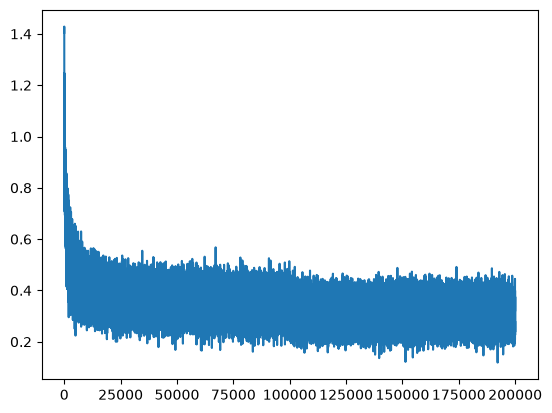

In [666]:
plt.plot(stepi, lossi)

In [667]:
emb = C[Xtr]  # (BATCH_SIZE, BLOCK_SIZE, 2)
h = torch.tanh(emb.view(-1, EMB_DIM * BLOCK_SIZE) @ W1 + b1)  # (BATCH_SIZE, 100)
logits = h @ W2 + b2  # (BATCH_SIZE, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0903, grad_fn=<NllLossBackward0>)

In [668]:
emb = C[Xdev]  # (BATCH_SIZE, BLOCK_SIZE, 2)
h = torch.tanh(emb.view(-1, EMB_DIM * BLOCK_SIZE) @ W1 + b1)  # (BATCH_SIZE, 100)
logits = h @ W2 + b2  # (BATCH_SIZE, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1471, grad_fn=<NllLossBackward0>)

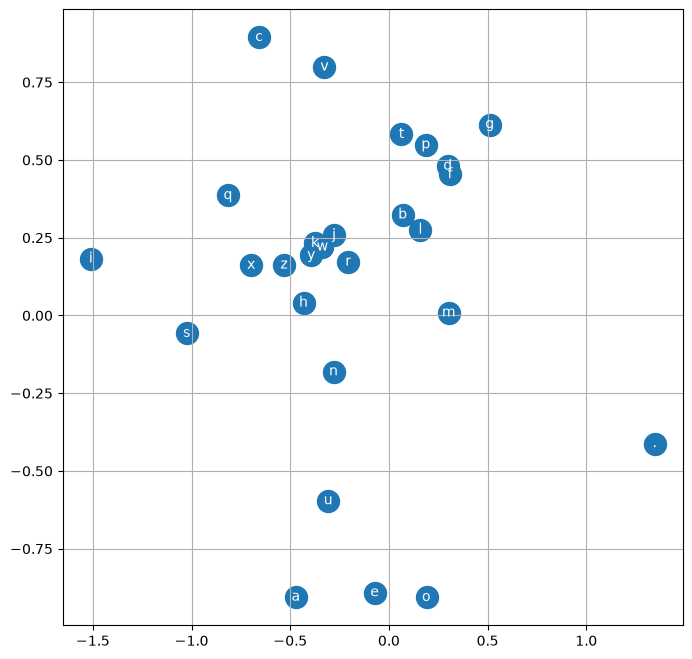

In [669]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=HIDDEN_LAYER_SIZE)
for i in range(C.shape[0]):
    plt.text(
        C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white"
    )
plt.grid("minor")

In [670]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [671]:
context = [0] * BLOCK_SIZE
C[torch.tensor([context])].shape

torch.Size([1, 3, 12])

In [672]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1,BLOCK_SIZE,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

carmah.
amelle.
khi.
mili.
taty.
skanden.
jazonel.
deliah.
jarqui.
nellara.
chaiim.
kaleigh.
ham.
join.
quinn.
suline.
liven.
corterri.
jaryxt.
frae.
